**Specifications**

In [1]:
fs = 44100 ##samples/seconds 1/fs ms between samples
fc = 4000 ##carrier wave frequency in Hz 
Ts = 2.2676e-3 ##each symbol is 2.2676 ms long (chosen so N = fs*Ts = 100 samples exactly)
μ = 0.00022676 ##maximum delay of the channel in seconds (0.22676 ms = Ts/10)
import numpy as np
import matplotlib.pyplot as plt

N = int(round(fs * Ts)) ##number of samples per symbol (= 100)
mu = int(round(fs * μ)) ##maximum delay of the channel in samples (= 10 samples)
alpha = 3/18 ## multipath amplitude coefficient


**Random Bit Generation**

In [2]:
bits = np.random.randint(0, 2, 1000000) ##generate random bits to transmit

**I/Q Mapping**

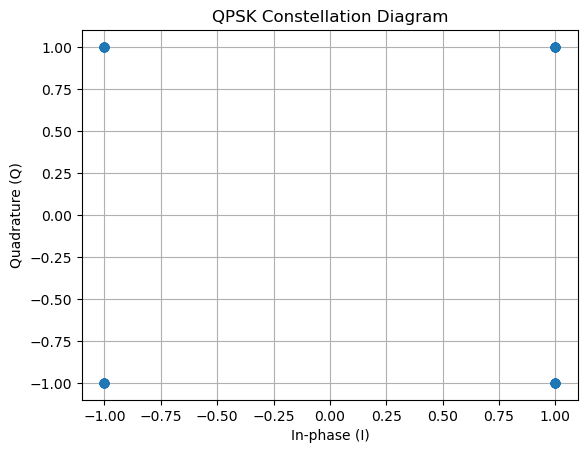

In [3]:
b = bits.reshape(-1, 2) ##reshape bits into pairs for QPSK modulation
aI = np.where(b[:, 0] == 0,  1.0, -1.0)  ##map the first bit of each pair to the in-phase component
aQ = np.where(b[:, 1] == 0,  1.0, -1.0)  ##map the second bit of each pair to the quadrature component

a = aI + 1j * aQ ##combine in-phase and quadrature components


plt.plot(aI[:100], aQ[:100], 'o')
plt.xlabel('In-phase (I)'); plt.ylabel('Quadrature (Q)')
plt.title('QPSK Constellation Diagram')
plt.grid(); plt.show()

**Pulse generation**

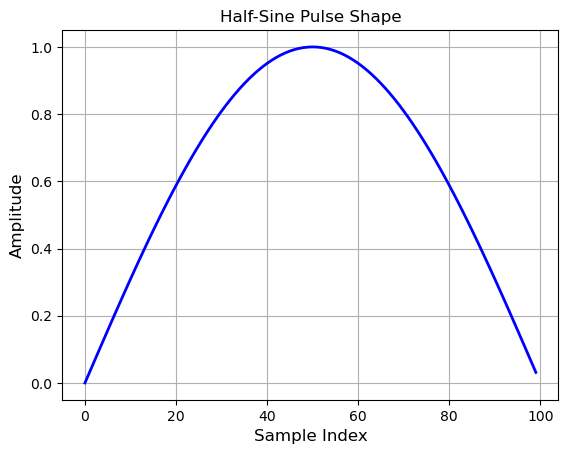

In [4]:
p = np.sin(np.pi * np.arange(N) / N) ## Base pulse (half-sine)
plt.plot(p, 'b-', lw=2)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Half-Sine Pulse Shape', fontsize=12)
plt.grid()
plt.show()

**Baseband Signal Generation**

In [5]:
Ns = len(a) ##number of symbols (pairs of bits) to transmit

# --- Option 1: Kronecker product (simplest, from lecture hint) ---
# np.kron(aI, p) stacks [aI[0]*p, aI[1]*p, ..., aI[Ns-1]*p] into one vector
#I_bb = np.kron(aI, p)
#Q_bb = np.kron(aQ, p)

# --- Option 2: Convolution (fix: use mode='full' then trim) ---
# mode='same' shifts by (N-1)//2 samples, misaligning pulses from their N-sample blocks
I_up = np.zeros(Ns * N)
Q_up = np.zeros(Ns * N)
I_up[::N] = aI
Q_up[::N] = aQ
I_bb = np.convolve(I_up, p, mode='full')[:Ns * N]
Q_bb = np.convolve(Q_up, p, mode='full')[:Ns * N]

**Carrier Generation**

In [6]:
n  = np.arange(Ns * N) ##time index for the entire transmitted signal (Ns symbols, each with N samples)
cos_c = np.cos(2 * np.pi * fc * n / fs) # carrier wave for upconversion
sin_c = np.sin(2 * np.pi * fc * n / fs) # carrier wave for upconversion

**Modulation**

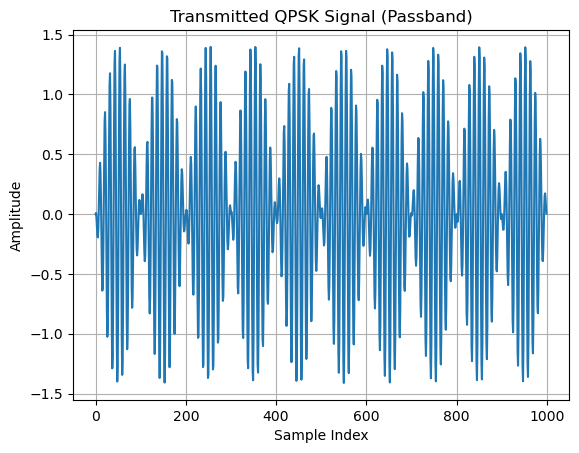

In [7]:
s_passband = I_bb * cos_c - Q_bb * sin_c   # upconvert to passband
plt.plot(s_passband[:1000]) ##plot the first 1000 samples of the transmitted signal
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Transmitted QPSK Signal (Passband)')
plt.grid()
plt.show()

**Channel**

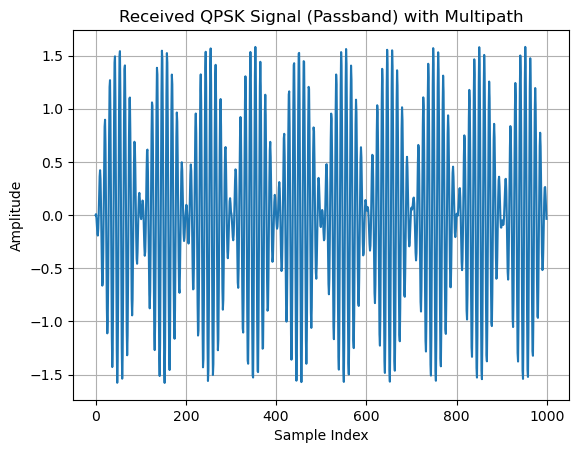

In [8]:
s_delayed = np.concatenate([np.zeros(mu), s_passband[:-mu]])
r = np.sqrt(1 - alpha**2) * s_passband + alpha * s_delayed
plt.plot(r[:1000])
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Received QPSK Signal (Passband) with Multipath')
plt.grid()
plt.show()

**Noise Generator**

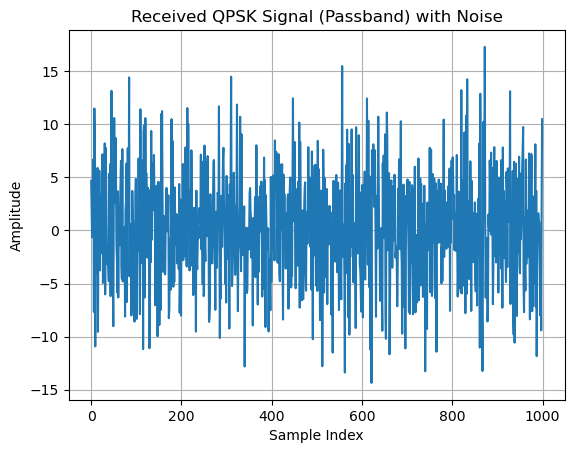

In [9]:
sigma = 5.0
noise = sigma * np.random.randn(len(r))
r = r + noise
plt.plot(r[:1000])
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Received QPSK Signal (Passband) with Noise')
plt.grid()
plt.show()

Eb/N0 =  0 dB  BER = 5.85e-02
Eb/N0 =  1 dB  BER = 3.95e-02
Eb/N0 =  2 dB  BER = 2.47e-02
Eb/N0 =  3 dB  BER = 1.39e-02
Eb/N0 =  4 dB  BER = 7.03e-03
Eb/N0 =  5 dB  BER = 3.01e-03
Eb/N0 =  6 dB  BER = 1.02e-03
Eb/N0 =  7 dB  BER = 3.12e-04
Eb/N0 =  8 dB  BER = 7.50e-05
Eb/N0 =  9 dB  BER = 1.40e-05
Eb/N0 = 10 dB  BER = 2.00e-06
Eb/N0 = 11 dB  BER = 0.00e+00
Eb/N0 = 12 dB  BER = 0.00e+00


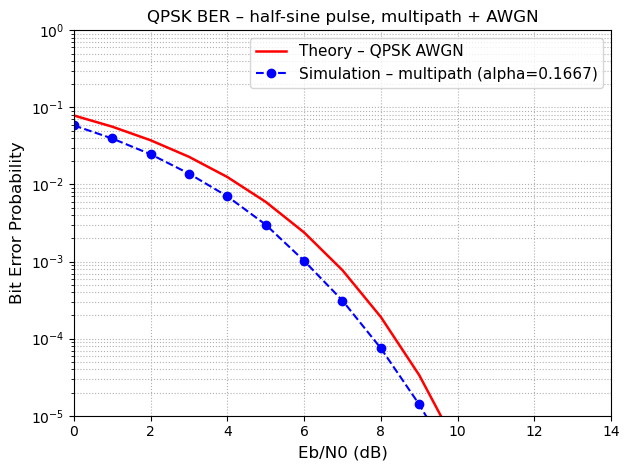

In [10]:
from scipy.special import erfc

EbN0_dB  = np.arange(0, 13, 1)          # 0..14 dB — reaches BER ~1e-4 for QPSK
EbN0_lin = 10 ** (EbN0_dB / 10.0)

Eb_disc = np.sum(s_passband**2) / (len(bits))   # discrete energy per bit

BER_sim = np.zeros(len(EbN0_dB))

for i, EbN0 in enumerate(EbN0_lin):
    sigma = np.sqrt(Eb_disc / (2.0 * EbN0))

    # Channel
    s_delayed = np.concatenate([np.zeros(mu), s_passband[:-mu]])
    r = np.sqrt(1 - alpha**2) * s_passband + alpha * s_delayed
    r = r + sigma * np.random.randn(len(r))

    # Downconvert
    r_I = 2.0 * r * cos_c
    r_Q = -2.0 * r * sin_c

    # Sample at MF output peaks (offset N-1 within each symbol period)
    idx  = np.arange(Ns) * N + (N - 1)
    y_I = r_I.reshape(Ns, N) @ p
    y_Q  = r_Q.reshape(Ns, N) @ p

    # Hard decisions
    bits_I_hat = (y_I < 0).astype(int)
    bits_Q_hat = (y_Q < 0).astype(int)
    bits_hat   = np.column_stack([bits_I_hat, bits_Q_hat]).flatten()
    BER_sim[i] = np.sum(bits != bits_hat) / len(bits)
    print(f'Eb/N0 = {EbN0_dB[i]:2d} dB  BER = {BER_sim[i]:.2e}')

# Theoretical QPSK BER in AWGN
BER_theory = 0.5 * erfc(np.sqrt(EbN0_lin))

plt.semilogy(EbN0_dB, BER_theory, 'r-',   lw=1.8, label='Theory – QPSK AWGN')
plt.semilogy(EbN0_dB, BER_sim,    'bo--',  lw=1.5, markersize=6,
             label=f'Simulation – multipath (alpha={alpha:.4f})')
plt.xlabel('Eb/N0 (dB)', fontsize=12)
plt.ylabel('Bit Error Probability', fontsize=12)
plt.title('QPSK BER – half-sine pulse, multipath + AWGN', fontsize=12)
plt.xlim([0, 14]); plt.ylim([1e-5, 1])
plt.legend(fontsize=11)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.savefig('ber_task1.pdf', bbox_inches='tight')
plt.show()